In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=.8,random_state=42)

RN=RandomForestClassifier()
RN.fit(X_train,y_train)

result=RN.predict(X_test)
print(result)

print(f"Accuracy score:{accuracy_score(y_test,result)*100}")

print("Feature name:",iris.feature_names)
print("Feature data:",iris.data[:5])
print('Target Name:',iris.target_names)
print("target Value:",iris.target)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy score:100.0
Feature name: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Feature data: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Target Name: ['setosa' 'versicolor' 'virginica']
target Value: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# ১. ডাটা লোড করা
iris = load_iris()
X = iris.data  # বৈশিষ্ট্য (পাপড়ির দৈর্ঘ্য, প্রস্থ ইত্যাদি)
y = iris.target # লক্ষ্য (ফুলের প্রজাতি)

# ২. ডাটাকে ট্রেনিং এবং টেস্টিং সেটে ভাগ করা (৮০% ট্রেনিং, ২০% টেস্টিং)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ৩. একটি মেশিন লার্নিং মডেল তৈরি করা (Random Forest)
model = RandomForestClassifier()

# ৪. মডেলকে ট্রেনিং দেওয়া
model.fit(X_train, y_train)

# ৫. মডেল দিয়ে প্রেডিকশন করা
predictions = model.predict(X_test)

# ৬. মডেল কতটা নির্ভুল তা চেক করা
accuracy = accuracy_score(y_test, predictions)
print(f"মডেলের নির্ভুলতা (Accuracy): {accuracy * 100}%")

# ৭. নতুন কোনো ডাটা দিয়ে পরীক্ষা করা
# ধরুন একটি নতুন ফুলের মাপ: ৫.১ সেমি, ৩.৫ সেমি, ১.৪ সেমি, ০.২ সেমি
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)
print(f"নতুন ফুলটি সম্ভবত: {iris.target_names[prediction][0]}")

মডেলের নির্ভুলতা (Accuracy): 100.0%
নতুন ফুলটি সম্ভবত: setosa


## House Price prediction

In [5]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ১. ডাটা লোড করা
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target # দাম (লক্ষ ডলারে)

# ২. ডাটা এক্সপ্লোরেশন (প্রথম ৫টি সারি দেখা)
print("Dataset Head:")
print(df.head())

# ৩. ফিচার এবং টার্গেট আলাদা করা
X = df.drop('Price', axis=1)
y = df['Price']

# ৪. ডাটা স্প্লিট করা (৮০% ট্রেনিং, ২০% টেস্টিং)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ৫. ফিচার স্কেলিং (Medium Level প্রজেক্টে এটি খুব জরুরি)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ৬. মডেল তৈরি এবং ট্রেনিং (Random Forest Regressor)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# ৭. প্রেডিকশন এবং মূল্যায়ন
predictions = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\nMean Absolute Error: {mae:.2f}") # গড়ে কত ভুল হচ্ছে
print(f"R2 Score: {r2:.2f}") # মডেলটি কতটা ভালো (১ এর কাছাকাছি মানে খুব ভালো)

# ৮. ইনভার্স ট্রান্সফর্মের ধারণা (ঐচ্ছিক)
# যদি আমরা ফিচারগুলোকে আগের অবস্থায় দেখতে চাই:
# original_X_test = scaler.inverse_transform(X_test_scaled)

Dataset Head:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Mean Absolute Error: 0.33
R2 Score: 0.81


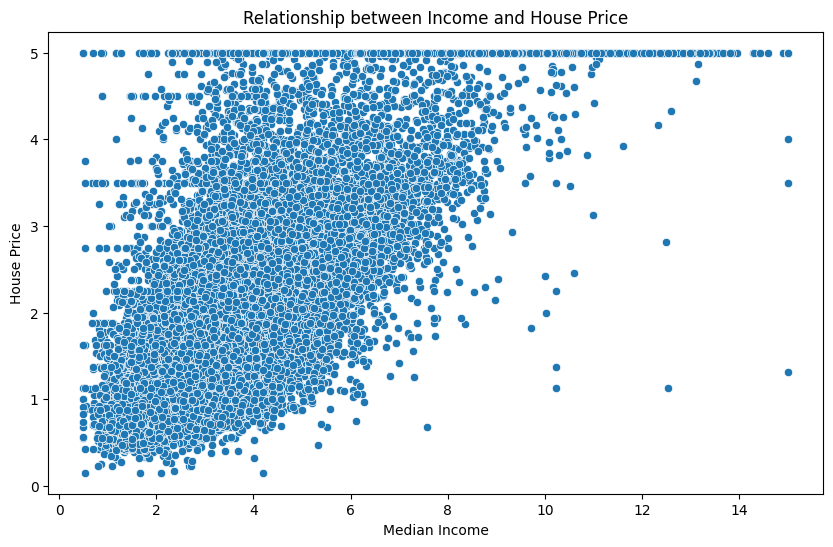

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ১. Scatter Plot: Median Income vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MedInc', y='Price', data=df)
plt.title('Relationship between Income and House Price')
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.show()

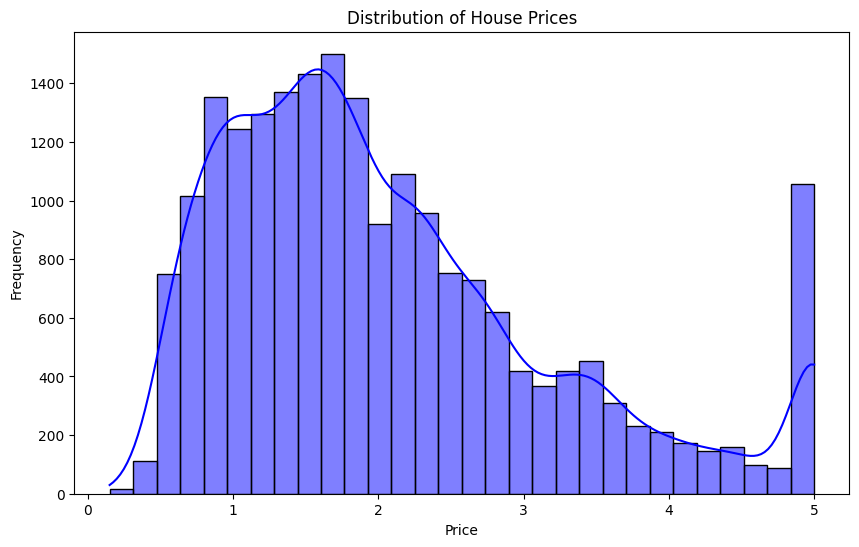

In [8]:
# ২. Histogram: Distribution of House Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

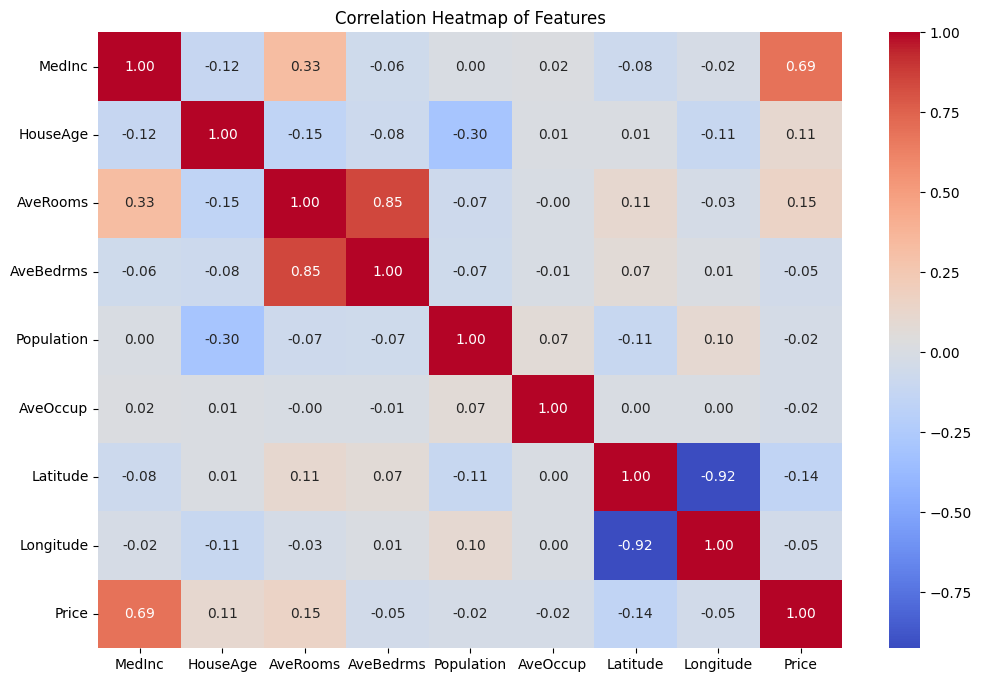

In [9]:
# ৩. Heatmap: Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr() # সব কলামের মধ্যে সম্পর্ক বের করা
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

## Heart Disease Prediction

   ï»¿age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      63    1   3       145   233    1        0      150      0      2.3   
1      37    1   2       130   250    0        1      187      0      3.5   
2      41    0   1       130   204    0        0      172      0      1.4   
3      56    1   1       120   236    0        1      178      0      0.8   
4      57    0   0       120   354    0        1      163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  

Accuracy Score: 0.8524590163934426

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0

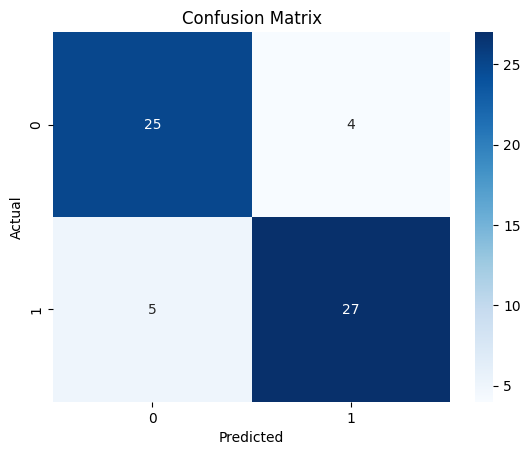

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

# ১. ডাটা লোড করা (সরাসরি অনলাইন সোর্স থেকে)
path = r"C:\Users\Uthoaingyo\Python\ML\heart.csv" 
df = pd.read_csv(path, encoding='latin1')

# ২. ডাটা দেখা (প্রথম ৫টি সারি)
print(df.head())

# ৩. ফিচার (X) এবং টার্গেট (y) আলাদা করা
# এখানে 'target' কলামটি হলো আমাদের আউটপুট (১ = অসুস্থ, ০ = সুস্থ)
X = df.drop('target', axis=1)
y = df['target']

# ৪. ডাটা স্প্লিট করা
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ৫. ফিচার স্কেলিং
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ৬. মডেল তৈরি এবং ট্রেনিং (Logistic Regression ব্যবহার করা হয়েছে)
model = LogisticRegression()
model.fit(X_train, y_train)

# ৭. প্রেডিকশন
y_pred = model.predict(X_test)

# ৮. মডেলের পারফরম্যান্স দেখা
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ৯. Confusion Matrix ভিজুয়ালাইজেশন
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [17]:
import pandas as pd

# আপনার পিসির সম্পূর্ণ পাথটি এখানে দিন
path = r"C:\Users\Uthoaingyo\Python\ML\heart.csv" 
df = pd.read_csv(path, encoding='latin1')

print(df.head())

   ï»¿age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      63    1   3       145   233    1        0      150      0      2.3   
1      37    1   2       130   250    0        1      187      0      3.5   
2      41    0   1       130   204    0        0      172      0      1.4   
3      56    1   1       120   236    0        1      178      0      0.8   
4      57    0   0       120   354    0        1      163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  


## "Handwritten Digit Classification"।

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ১. ডাটা লোড করা (MNIST ডাটাসেট বিল্ট-ইন থাকে)
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# ২. ডাটা নরমালাইজেশন (ইমেজ পিক্সেল ০-২৫৫ থেকে ০-১ এর মধ্যে আনা)
X_train, X_test = X_train / 255.0, X_test / 255.0

# ৩. ইমেজগুলো কেমন দেখতে তা চেক করা
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# ৪. মডেল তৈরি করা (Neural Network)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)), # ২৮x২৮ পিক্সেলকে এক সারিতে আনা
    layers.Dense(128, activation='relu'),   # হিডেন লেয়ার
    layers.Dropout(0.2),                   # ওভারফিটিং কমানোর জন্য
    layers.Dense(10, activation='softmax') # আউটপুট লেয়ার (০-৯ পর্যন্ত ১০টি ক্লাস)
])

# ৫. মডেল কম্পাইল করা
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ৬. মডেল ট্রেনিং দেওয়া
print("Training the model...")
model.fit(X_train, y_train, epochs=5)

# ৭. মডেল মূল্যায়ন করা
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')

Loading data...
Training the model (SVM)...
Accuracy: 83.50%


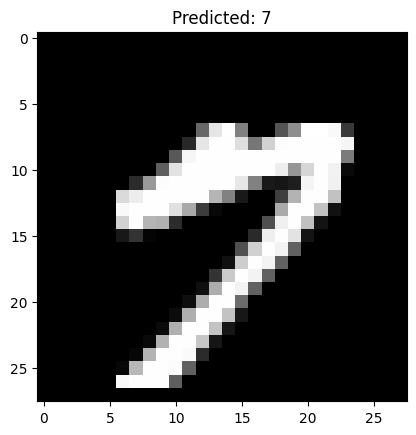

In [20]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ১. MNIST ডাটা লোড করা (এটি একটু সময় নিতে পারে)
print("Loading data...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# ২. ডাটা নরমালাইজেশন
# পিক্সেল ভ্যালু ০-২৫৫ থেকে ০-১ এ আনা
X = X / 255.0

# ৩. ডাটা স্প্লিট করা (পুরো ৭০ হাজার ডাটা নিতে অনেক সময় লাগবে, তাই আমরা ১০ হাজার নিচ্ছি)
X_train, X_test, y_train, y_test = train_test_split(X[:1000], y[:1000], test_size=0.2, random_state=42)

# ৪. মডেল তৈরি এবং ট্রেনিং (SVM ব্যবহার করছি)
print("Training the model (SVM)...")
model = SVC(kernel='poly', degree=3) # পলিনোমিয়াল কার্নেল ইমেজের জন্য ভালো
model.fit(X_train, y_train)

# ৫. প্রেডিকশন এবং একুরেসি চেক
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")

# ৬. একটি ইমেজ টেস্ট করা
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predictions[0]}")
plt.show()

## "Customer Segmentation" Unsupervised Learning

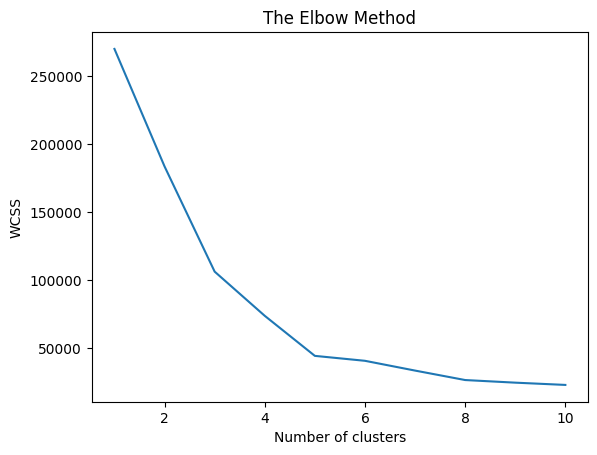

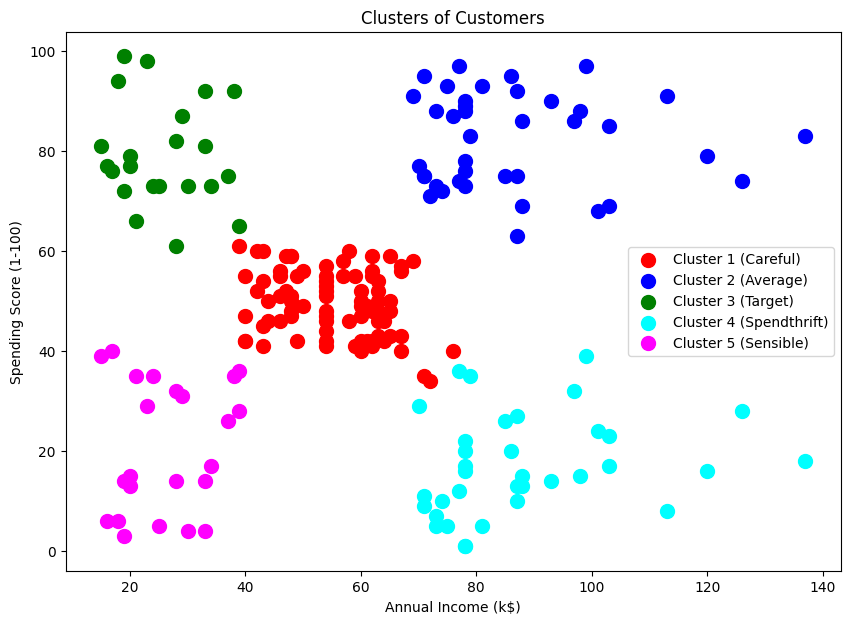

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# ১. ডাটা লোড করা
path = r"C:\Users\Uthoaingyo\Python\ML\Mall_Customers.csv" 
df = pd.read_csv(path, encoding='latin1')

# ২. ফিচার সিলেক্ট করা (আমরা শুধু Annual Income এবং Spending Score নিচ্ছি)
# কলাম ইন্ডেক্স ৩ এবং ৪
X = df.iloc[:, [3, 4]].values

# ৩. 'Elbow Method' ব্যবহার করে সেরা ক্লাস্টার সংখ্যা (K) বের করা
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# ৪. মডেল ট্রেনিং (ধরি K = 5, এলবো গ্রাফ থেকে পাওয়া)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# ৫. ভিজুয়ালাইজেশন (ক্লাস্টারগুলো দেখা)
plt.figure(figsize=(10,7))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1 (Careful)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2 (Average)')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3 (Target)')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4 (Spendthrift)')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5 (Sensible)')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()